# Atividade Prática — Aula 1  
## Python para Análise de Dados: do dado bruto à decisão estratégica

Nesta atividade, você vai aplicar os conceitos apresentados na aula usando um dataset simulado de vendas no varejo brasileiro.

**Arquivo de dados:** `vendas_brasil_aula1.csv`  
**Objetivo:** praticar leitura de dados, inspeção inicial, qualidade dos dados, KPIs e escolha de visualizações.

---
### O que você vai treinar
- Entender o pipeline básico de análise
- Inspecionar um dataset com `pandas`
- Identificar problemas de qualidade de dados
- Definir KPIs de negócio
- Escolher gráficos adequados para responder perguntas do gestor

## Instruções
1. Faça upload do arquivo `vendas_brasil_aula1.csv` no Google Colab ou deixe-o na mesma pasta do notebook.
2. Execute as células na ordem.
3. Responda às perguntas **no próprio notebook**, em células de texto ou código.
4. Sempre que possível, explique **o que o resultado significa para o negócio**.

## Dataset utilizado

O arquivo contém registros de vendas com as seguintes colunas:

- `Data_Venda`: data da venda
- `Canal_Venda`: canal comercial
- `UF`: estado da venda
- `Produto`: produto vendido
- `Preco_Unitario`: preço unitário
- `Quantidade`: quantidade vendida
- `Custo_Unitario`: custo unitário do item
- `Receita`: valor total da venda
- `Lucro`: lucro total da venda

> Atenção: o dataset foi preparado com **alguns problemas de qualidade propositalmente**, para que você pratique inspeção e limpeza.

## 1) Preparação do ambiente
Execute a célula abaixo para importar a biblioteca principal da atividade.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

## 2) Leitura do arquivo
Altere o caminho do arquivo, se necessário.

In [2]:
df = pd.read_csv("vendas_brasil_aula1.csv")
df.head()

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,2025-04-13,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,2025-06-29,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,2025-04-03,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,2025-01-15,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,2025-04-17,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


## 3) Atividade 1 — Entendendo o dataset

Responda às perguntas abaixo usando código:

1. Quantas linhas e colunas existem no dataset?
2. Quais são os nomes das colunas?
3. Quais são os tipos de dados de cada coluna?

> Dica: use `shape`, `columns` e `info()`.

In [3]:
df.shape

(300, 9)

In [4]:
df.columns

Index(['Data_Venda', 'Canal_Venda', 'UF', 'Produto', 'Preco_Unitario',
       'Quantidade', 'Custo_Unitario', 'Receita', 'Lucro'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Data_Venda      300 non-null    object 
 1   Canal_Venda     293 non-null    object 
 2   UF              294 non-null    object 
 3   Produto         300 non-null    object 
 4   Preco_Unitario  295 non-null    float64
 5   Quantidade      300 non-null    int64  
 6   Custo_Unitario  300 non-null    float64
 7   Receita         300 non-null    float64
 8   Lucro           300 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 21.2+ KB


## 4) Atividade 2 — Qualidade dos dados

Agora investigue se existem problemas de qualidade.

Responda:

1. Existem valores nulos?
2. Em quais colunas eles aparecem?
3. Existem categorias escritas de formas diferentes para o mesmo canal de venda?

> Dica: use `isnull().sum()` e `value_counts()`.

In [28]:
df.isnull().sum() # 7 valores nulos em Canal_Venda 6 em UF e 5 em Preço_Unitario
df.dropna() # Limpando os valores ausentes e nulos do dataset

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,2025-04-13,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,2025-06-29,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,2025-04-03,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,2025-01-15,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,2025-04-17,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92
...,...,...,...,...,...,...,...,...,...
295,2025-06-25,WhatsApp,RJ,Teclado Mecânico,536.47,2,294.57,1072.94,483.80
296,2025-04-25,E-commerce,ES,Teclado Mecânico,442.05,1,243.60,442.05,198.45
297,2025-04-29,Loja Física,RS,Fone Bluetooth,297.57,1,173.04,297.57,124.53
298,2025-01-22,Loja Física,ES,Teclado Mecânico,413.94,1,223.01,413.94,190.93


In [33]:
df['Canal_Venda'] = df['Canal_Venda'].replace({'loja fisica': 'Loja Física', 'e-commerce': 'E-commerce'}) # Consertando o erro dos valores inconsistentes
df['Canal_Venda'].value_counts() # Definindo a quantidade de canais de venda no dataset


,count
Canal_Venda,
Loja Física,107
E-commerce,107
Marketplace,42
WhatsApp,37


In [51]:
df['Data_Venda'] = pd.to_datetime(df['Data_Venda'], format='%Y-%m-%d') # Garante que a coluna é do tipo datetime
df['Data_Venda'] = df['Data_Venda'].dt.strftime('%d/%m/%Y') # Converte para o formato brasileiro (DD/MM/YYYY)
df

ValueError: time data "13/04/2025" doesn't match format "%Y-%m-%d", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

## 5) Atividade 3 — KPIs do negócio

Considere que você é analista de um varejista e precisa apresentar indicadores para a gestão.

Calcule os seguintes KPIs:

1. **Receita total**
2. **Lucro total**
3. **Ticket médio** (`Receita média por registro`)
4. **Quantidade total vendida**

Depois, escreva uma breve interpretação:
- O desempenho geral parece positivo?
- Receita e lucro caminham juntos?

In [52]:
df.head()

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,13/04/2025,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,29/06/2025,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,03/04/2025,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,15/01/2025,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,17/04/2025,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


In [53]:
df['Receita'].sum() # Receita Total
# R$ 707.535,36

np.float64(707535.36)

In [54]:
df['Lucro'].sum() # Lucro Total
# R$ 189.625,88

np.float64(189625.88)

In [55]:
Ticket_medio = df['Receita'].sum()/ df['Quantidade'].sum() # Valor do Ticket_Medio da Empresa
Ticket_medio

np.float64(1409.4329880478087)

In [56]:
quantidade_total = df['Quantidade'].sum() #Calculo da quantidade total de vendas
quantidade_total

np.int64(502)

## 6) Atividade 4 — Respondendo perguntas do gestor com dados

Use o dataset para responder:

1. **Qual canal gera mais receita?**
2. **Qual produto gera mais lucro?**
3. **Quais UFs concentram maior receita?**

Para cada resposta:
- mostre o código;
- apresente o resultado;
- escreva uma interpretação curta.

In [57]:
df.head()

,Data_Venda,Canal_Venda,UF,Produto,Preco_Unitario,Quantidade,Custo_Unitario,Receita,Lucro
0,13/04/2025,Loja Física,SP,Smartphone,2484.58,3,1872.49,7453.74,1836.27
1,29/06/2025,Loja Física,RJ,Smartwatch,1041.91,1,699.66,1041.91,342.25
2,03/04/2025,E-commerce,RJ,Smartphone,2447.07,1,2077.09,2447.07,369.98
3,15/01/2025,Loja Física,MG,Smartphone,2307.40,1,1797.67,2307.40,509.73
4,17/04/2025,E-commerce,PR,Notebook,3840.18,4,3069.45,15360.72,3082.92


In [58]:
df.groupby('Canal_Venda')['Receita'].sum().sort_values(ascending=False)# Agrupamento de Receita por Canal

,Receita
Canal_Venda,
E-commerce,249338.01
Loja Física,235645.31
Marketplace,111659.78
WhatsApp,85974.51


In [59]:
df.groupby('Produto')['Lucro'].sum().sort_values(ascending=False) # Agrupamento de Lucro por produto

,Lucro
Produto,
Notebook,69818.57
Smartphone,31718.11
Tablet,20936.95
Monitor,18290.52
Smartwatch,17029.45
Teclado Mecânico,12859.48
Fone Bluetooth,11647.92
Mouse Gamer,7324.88


In [60]:
df.groupby('UF')['Receita'].sum().sort_values(ascending=False) # Definição das UF´s com maior receita

,Receita
UF,
SP,133727.80
MG,103438.61
RJ,100284.68
PR,69287.74
SC,63740.20
RS,51020.06
ES,50338.64
BA,46765.01
PE,42895.39


## 7) Atividade 5 — Escolhendo a visualização certa

Sem necessariamente construir os gráficos ainda, responda:

a) Qual gráfico você usaria para mostrar a **evolução da receita ao longo do tempo**?  
b) Qual gráfico você usaria para **comparar a receita entre canais de venda**?  
c) Qual gráfico você usaria para mostrar a **distribuição dos preços unitários**?

Em seguida, gere **ao menos um gráfico** com `pandas` ou `matplotlib`.

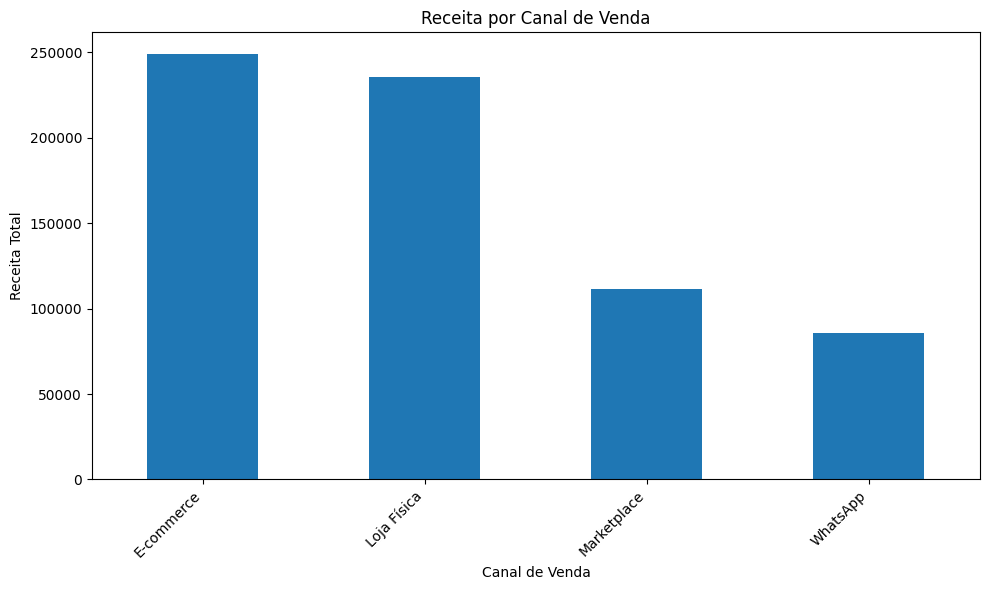

In [72]:
from matplotlib import lines
# a) linha
# b) Barra
# c) Histograma

# Agrupando a receita por Canal_Venda e plotando como gráfico de barras
df.groupby('Canal_Venda')['Receita'].sum().plot(kind='bar', figsize=(10, 6))
plt.title('Receita por Canal de Venda')
plt.xlabel('Canal de Venda')
plt.ylabel('Receita Total')
plt.xticks(rotation=45, ha='right') # Rotaciona os rótulos do eixo X para melhor visualização
plt.tight_layout() # Ajusta o layout para evitar cortes nos rótulos
plt.show()

In [23]:
# Sua resposta aqui

## Desafio extra (opcional)

Faça uma pequena limpeza no dataset:

- trate valores nulos;
- padronize os nomes dos canais de venda;
- converta `Data_Venda` para formato de data.

Depois, compare os resultados **antes e depois da limpeza**.

In [ ]:
# Sua resposta aqui

## Entrega esperada

Ao final, seu notebook deve conter:

- leitura do dataset;
- inspeção inicial;
- análise de qualidade dos dados;
- cálculo de KPIs;
- respostas às perguntas de negócio;
- pelo menos um gráfico;
- comentários interpretando os resultados.

---
### Reflexão final
Explique em 4 a 6 linhas:

**Por que uma análise de dados não deve se limitar a “fazer gráficos bonitos”?**

### O gráfico precisa apresentar insights e informações que sejam relevantes para a resolução de um problema de negócio, deve ser limpo e o mais claro possível, além de apresentar KPI´s e análises que ajudam o desenvolvimento de uma empresa